<a href="https://colab.research.google.com/github/srijalgiri/Ai-ML_sem6/blob/main/241993_Worksheet4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6CS012 - Worksheet 4


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



## Task 1: Data Preparation



In [8]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from PIL import Image
import matplotlib.pyplot as plt


dataset_path = "/content/drive/MyDrive/DevanagariHandwrittenDigitDataset"

train_dir = os.path.join(dataset_path, "/content/drive/MyDrive/DevanagariHandwrittenDigitDataset/Train")
test_dir  = os.path.join(dataset_path, "/content/drive/MyDrive/DevanagariHandwrittenDigitDataset/Test")

# Image dimensions expected by the model
IMG_HEIGHT, IMG_WIDTH = 28, 28
NUM_CLASSES = 10

def load_images_from_folder(folder):
    """
    Walk through each class sub-folder, load every image with PIL,
    resize to 28x28, convert to grayscale, normalise to [0, 1].
    Returns:
        images : np.ndarray  shape (N, 28, 28)
        labels : np.ndarray  shape (N,)  integer class indices
    """
    images, labels = [], []

    class_names = sorted(os.listdir(folder))
    class_map   = {name: idx for idx, name in enumerate(class_names)}
    print(f"Classes found: {class_map}")

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):
            continue
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            try:
                img = Image.open(img_path).convert("L")
                img = img.resize((IMG_WIDTH, IMG_HEIGHT))
                img_array = np.array(img) / 255.0
                images.append(img_array)
                labels.append(label)
            except Exception as e:
                print(f"  Skipping {img_path}: {e}")

    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.int32)


print("Loading training data ...")
x_train_raw, y_train_raw = load_images_from_folder(train_dir)

print("\nLoading test data ...")
x_test_raw,  y_test_raw  = load_images_from_folder(test_dir)

print(f"\nRaw training set : {x_train_raw.shape}, labels: {y_train_raw.shape}")
print(f"Raw test set     : {x_test_raw.shape},  labels: {y_test_raw.shape}")

Loading training data ...
Classes found: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}

Loading test data ...
Classes found: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}

Raw training set : (17000, 28, 28), labels: (17000,)
Raw test set     : (3000, 28, 28),  labels: (3000,)


In [9]:

x_train_flat = x_train_raw.reshape(-1, IMG_HEIGHT * IMG_WIDTH)
x_test_flat  = x_test_raw.reshape(-1,  IMG_HEIGHT * IMG_WIDTH)
y_train = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_raw,  num_classes=NUM_CLASSES)

print("Flattened training set :", x_train_flat.shape, "| one-hot labels:", y_train.shape)
print("Flattened test set     :", x_test_flat.shape,  "| one-hot labels:", y_test.shape)

Flattened training set : (17000, 784) | one-hot labels: (17000, 10)
Flattened test set     : (3000, 784) | one-hot labels: (3000, 10)


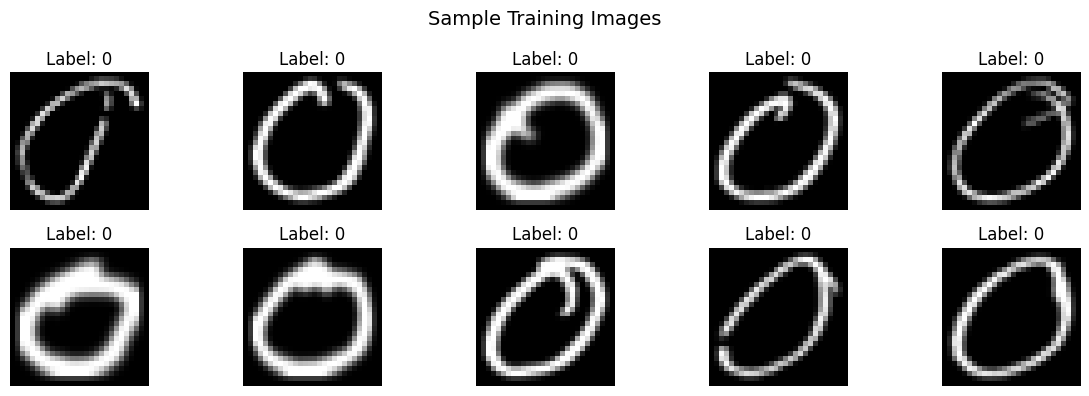

In [10]:

plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_raw[i], cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")
plt.suptitle("Sample Training Images", fontsize=14)
plt.tight_layout()
plt.show()


## Task 2: Build the FCN Model

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input

def build_fcn_model(input_dim=784, num_classes=10):
    model = Sequential([
        Input(shape=(input_dim,)),


        Dense(64,  activation='sigmoid', name='hidden_1'),

        Dense(128, activation='sigmoid', name='hidden_2'),

        Dense(256, activation='sigmoid', name='hidden_3'),

        Dense(num_classes, activation='softmax', name='output'),
    ], name='FCN_Devnagari')

    return model

model = build_fcn_model()
model.summary()

Model: "FCN_Devnagari"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)


## Task 3: Compile the Model


In [12]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.



## Task 4: Train the Model

In [13]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

BATCH_SIZE = 128
EPOCHS     = 20

callbacks = [

    ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
]

history = model.fit(
    x_train_flat, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2904 - loss: 1.9655
Epoch 1: val_loss improved from None to 7.35754, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.4907 - loss: 1.6244 - val_accuracy: 0.0000e+00 - val_loss: 7.3575
Epoch 2/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8299 - loss: 0.6370
Epoch 2: val_loss did not improve from 7.35754
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8593 - loss: 0.5036 - val_accuracy: 0.0000e+00 - val_loss: 8.9117
Epoch 3/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9212 - loss: 0.2905
Epoch 3: val_loss did not improve from 7.35754
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9293 - loss: 0.2602 - val_accuracy: 0.0000e+00 - val_loss: 9.7633
Epoch 4/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9447 - loss: 0.2012
Epoch 4: val_loss did not improve from 7.35754
107/107 ━━━━━━━━

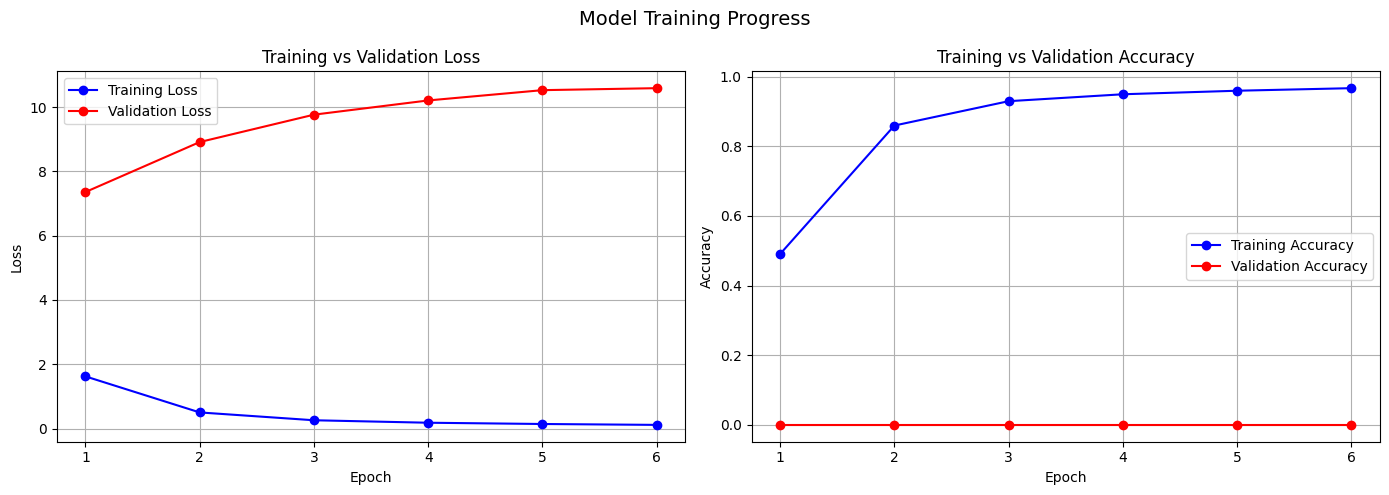

In [14]:

# Visualise Training & Validation Loss/Accuracy

train_loss = history.history['loss']
val_loss   = history.history['val_loss']
train_acc  = history.history['accuracy']
val_acc    = history.history['val_accuracy']
epochs_ran = range(1, len(train_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Loss ---
axes[0].plot(epochs_ran, train_loss, 'b-o', label='Training Loss')
axes[0].plot(epochs_ran, val_loss,   'r-o', label='Validation Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# --- Accuracy ---
axes[1].plot(epochs_ran, train_acc, 'b-o', label='Training Accuracy')
axes[1].plot(epochs_ran, val_acc,   'r-o', label='Validation Accuracy')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Model Training Progress', fontsize=14)
plt.tight_layout()
plt.show()


## Task 5: Evaluate the Model

In [15]:
test_loss, test_acc = model.evaluate(x_test_flat, y_test, verbose=2)

print(f"\n=== Test Results ===")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc * 100:.2f}%")

94/94 - 1s - 11ms/step - accuracy: 0.6223 - loss: 2.1330

=== Test Results ===
Test Loss     : 2.1330
Test Accuracy : 62.23%



## Task 6: Save and Load the Model

In [16]:

model.save('devnagari_fcn_model.h5')
print("Model saved to 'devnagari_fcn_model.h5'")

Model saved to 'devnagari_fcn_model.h5'


In [17]:

loaded_model = tf.keras.models.load_model('devnagari_fcn_model.h5')
print("Model loaded successfully.")
reloaded_loss, reloaded_acc = loaded_model.evaluate(x_test_flat, y_test, verbose=2)
print(f"\nReloaded model — Test Loss: {reloaded_loss:.4f} | Test Accuracy: {reloaded_acc * 100:.2f}%")

Model loaded successfully.
94/94 - 1s - 14ms/step - accuracy: 0.6223 - loss: 2.1330

Reloaded model — Test Loss: 2.1330 | Test Accuracy: 62.23%


---
## Task 7: Making Predictions

In [18]:

predictions = loaded_model.predict(x_test_flat, verbose=0)

predicted_labels = np.argmax(predictions, axis=1)
true_labels      = np.argmax(y_test,      axis=1)

print(f"Predicted label for first test image : {predicted_labels[0]}")
print(f"True label for first test image      : {true_labels[0]}")

Predicted label for first test image : 0
True label for first test image      : 0


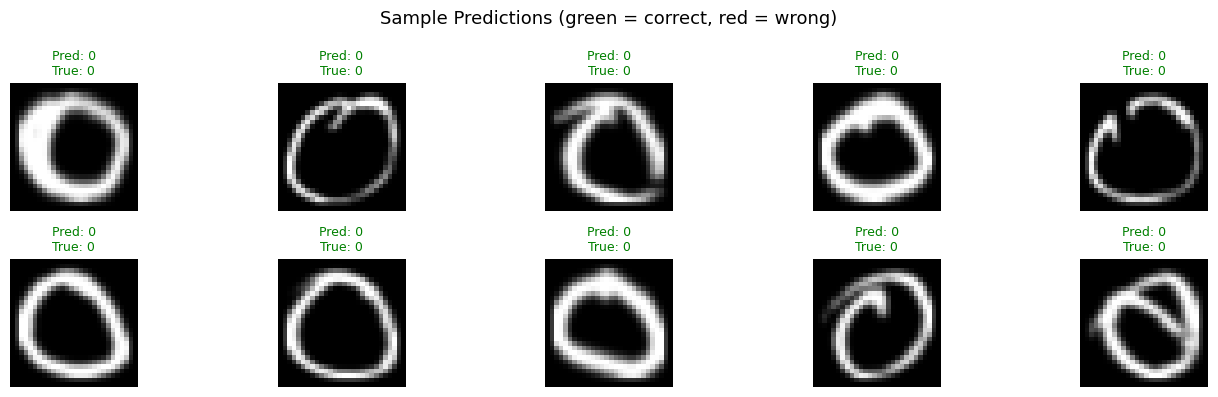

In [19]:

plt.figure(figsize=(14, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test_raw[i], cmap='gray')
    color = 'green' if predicted_labels[i] == true_labels[i] else 'red'
    plt.title(f"Pred: {predicted_labels[i]}\nTrue: {true_labels[i]}",
              color=color, fontsize=9)
    plt.axis('off')

plt.suptitle('Sample Predictions (green = correct, red = wrong)', fontsize=13)
plt.tight_layout()
plt.show()

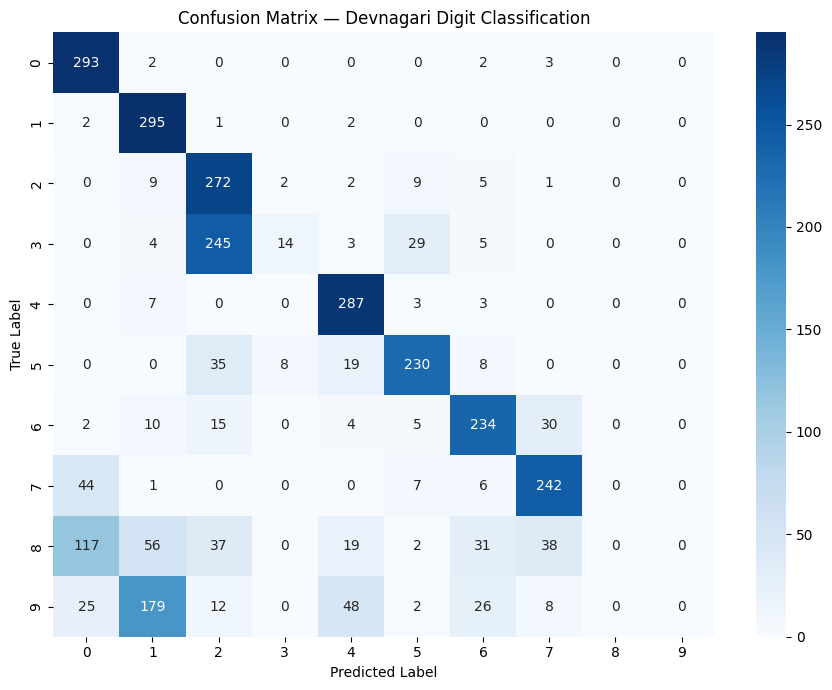


Classification Report:
              precision    recall  f1-score   support

     Digit 0       0.61      0.98      0.75       300
     Digit 1       0.52      0.98      0.68       300
     Digit 2       0.44      0.91      0.59       300
     Digit 3       0.58      0.05      0.09       300
     Digit 4       0.75      0.96      0.84       300
     Digit 5       0.80      0.77      0.78       300
     Digit 6       0.73      0.78      0.75       300
     Digit 7       0.75      0.81      0.78       300
     Digit 8       0.00      0.00      0.00       300
     Digit 9       0.00      0.00      0.00       300

    accuracy                           0.62      3000
   macro avg       0.52      0.62      0.53      3000
weighted avg       0.52      0.62      0.53      3000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [20]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix — Devnagari Digit Classification')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels,
                             target_names=[f'Digit {i}' for i in range(10)]))